In [ ]:
!pip install git+https://github.com/ranaroussi/yfinance.git

  Cloning https://github.com/ranaroussi/yfinance.git to /tmp/pip-req-build-9mbf5wt1
  Running command git clone --filter=blob:none --quiet https://github.com/ranaroussi/yfinance.git /tmp/pip-req-build-9mbf5wt1
  Resolved https://github.com/ranaroussi/yfinance.git to commit 4013a4fd745f6f3f324565eae685e7765b2a2714
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 91.3 MB/s eta 0:00:00
  Created wheel for yfinance: filename=yfinance-1.2.0-py2.py3-none-any.whl size=130142 sha256=4c2d1cac511456285f0dfccf1616267b9e5c7427aa372760a5cf3f0663247c40
  Stored in directory: /tmp/pip-ephem-wheel-cache-0xafwybh/wheels/10/84/01/c0b6e111c5af445cb9c523399c6e0acba700394426760f67b1
Successfully built yfinance
  Attempting uninstall: curl_cffi
    Found existing installation: curl_cffi 0.14.0
    Uninstalling curl_cffi-0.14.0:
      Successfully uninstalled curl_cffi-0.14.0
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    U

In [1]:
# @title Configuración e Importaciones
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import ipywidgets as widgets
from IPython.display import display
from google.colab import drive

# Montar Drive (si no está montado)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Asegurar que utils.py se pueda importar (asumiendo que está en el mismo directorio o path conocido)
# Si utils.py está en Drive, añadir el path
sys.path.append('/content/drive/MyDrive/Challenges_ML-DL') # Ajustar según estructura real en colab si es necesario
# O si se sube localmente:
# sys.path.append('.')

#import utils_new as utils
from utils import (
    tech_us_tickers, petroleo_us_tickers, banks_us_tickers, mining_us_tickers,
    LSTMMixedModel, calculate_phi_metric,
    save_processed_data_optimized, load_processed_data,
    engineer_features, create_sequences, fit_robust_normalization, apply_robust_normalization,
    get_triple_barrier_labels
)

import numpy as np
import pandas as pd
import sqlite3
import joblib
import copy
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Mounted at /content/drive
Usando dispositivo: cuda


In [2]:
# @title Selector de Sector y Modo
# Create dropdown for Sector
sector_dropdown = widgets.Dropdown(
    options=['Tech', 'Petroleo', 'Banks', 'Mining'],
    value='Tech',
    description='SECTOR:',
)

# Create dropdown for Mode
mode_dropdown = widgets.Dropdown(
    options=['Create Dataset', 'Train', 'Both'],
    value='Train',
    description='MODE:',
)

display(sector_dropdown)
display(mode_dropdown)

Dropdown(description='SECTOR:', options=('Tech', 'Petroleo', 'Banks', 'Mining'), value='Tech')

Dropdown(description='MODE:', index=1, options=('Create Dataset', 'Train', 'Both'), value='Train')

In [3]:
# @title Configuración Global (Ejecutar tras selección)

SECTOR_NAME = sector_dropdown.value
MODE = mode_dropdown.value

# Mapeo de selectores a variables
if SECTOR_NAME == 'Tech':
    tickers_dict = tech_us_tickers
    db_name = 'tech_us_tickers.db'
    h5_name = 'processed_tech_us_data.h5'
    model_name = 'tech_us_model.pth'
    scaler_name = 'scalers_tech_us.pkl'
elif SECTOR_NAME == 'Petroleo':
    tickers_dict = petroleo_us_tickers
    db_name = 'petroleo_us_tickers.db'
    h5_name = 'processed_petroleo_data.h5'
    model_name = 'petroleo_model.pth'
    scaler_name = 'scalers_petroleo.pkl'
elif SECTOR_NAME == 'Banks':
    tickers_dict = banks_us_tickers
    db_name = 'banks_us_tickers.db'
    h5_name = 'processed_bank_data.h5'
    model_name = 'banks_model.pth'
    scaler_name = 'scalers_banks.pkl'
elif SECTOR_NAME == 'Mining':
    tickers_dict = mining_us_tickers
    db_name = 'mining_us_tickers.db'
    h5_name = 'processed_mining_data.h5'
    model_name = 'mining_model.pth'
    scaler_name = 'scalers_mining.pkl'

BASE_PATH = '/content/drive/MyDrive/Challenges_ML-DL'
DB_PATH = os.path.join(BASE_PATH, 'datasets_db', db_name)
H5_PATH = os.path.join(BASE_PATH, 'datasets_db', h5_name)
MODEL_PATH = os.path.join(BASE_PATH, 'models', model_name)
SCALER_PATH = os.path.join(BASE_PATH, 'models', scaler_name)

print(f"--- CONFIGURACIÓN ---")
print(f"Sector: {SECTOR_NAME}")
print(f"Modo: {MODE}")
print(f"DB Path: {DB_PATH}")
print(f"H5 Path: {H5_PATH}")
print(f"Model Path: {MODEL_PATH}")

--- CONFIGURACIÓN ---
Sector: Mining
Modo: Train
DB Path: /content/drive/MyDrive/Challenges_ML-DL/datasets_db/mining_us_tickers.db
H5 Path: /content/drive/MyDrive/Challenges_ML-DL/datasets_db/processed_mining_data.h5
Model Path: /content/drive/MyDrive/Challenges_ML-DL/models/mining_model.pth


In [ ]:
# @title 1. Creación del Dataset (MODE: 'Create Dataset' o 'Both')

SEQ_LEN = 20
TBM_HORIZON = 2 # Barrera vertical

if MODE in ['Create Dataset', 'Both']:
    print(f"Probando conexión a DB: {DB_PATH}")
    # Verificar existencia de DB
    if not os.path.exists(DB_PATH):
        print(f"⚠️ La base de datos {DB_PATH} no existe. Asegúrate de haber descargado los datos.")
    else:
        conexion = sqlite3.connect(DB_PATH)
        tickers = list(tickers_dict.values())
        scalers = {}

        X_train_list, y_train_list = [], []
        X_val_list, y_val_list = [], []

        print(f"Procesando {len(tickers)} tickers...")

        for ticker in tickers:
            try:
                # 1. Leer Datos
                # Dependiendo de cómo se guardó en download_data, a veces la tabla es el ticker 'AAPL' o 'AAPL_US'
                # Intentamos leer la tabla con el nombre del ticker
                # Nota: En mining se reemplazaron '.' y '-' por '_'. Debemos replicar eso.
                table_name = ticker.replace("-", "_").replace(".", "_")

                query = f"SELECT name FROM sqlite_master WHERE type='table' AND name='{table_name}'"
                if pd.read_sql(query, conexion).empty:
                    # Intento fallback si el nombre no coincide exacto (aunque debería)
                    continue

                hist = pd.read_sql(f'SELECT * FROM {table_name}', conexion, index_col='Date')
                hist.index = pd.to_datetime(hist.index, utc=True)
                df = hist.copy()

                # 2. Feature Engineering
                # Llama a la funcion de utils
                df, full_df_labeled = engineer_features(df, hist['Close'])

                # Si engineer_features devuelve None en el segundo arg
                if full_df_labeled is None:
                    continue

                # 3. Etiquetado Triple Barrier (Ya hecho internamente? No, engineer_features retorna df para inferencia)
                # Re-mirando engineer_features en utils.py:
                # Retorna (df, full_df). full_df NO TIENE ETIQUETAS "Target" aun.
                # engineer_features en utils.py contiene:
                # full_df = pd.concat([ features... ], axis=1)
                # return df, full_df
                # FALTA EL ETIQUETADO Y COMBINACION CON TARGET.

                # Corrección: Necesitamos calcular Labels AQUI
                labels = get_triple_barrier_labels(df, t_final=TBM_HORIZON, k=1)

                # Unir Features + Labels
                # Alineamos índices con los datos de full_df (que ya está filtrado y procesado)
                full_df_final = pd.concat([full_df_labeled, labels.rename('Target')], axis=1).dropna()

                if len(full_df_final) < SEQ_LEN + 20: continue

                feature_cols = [c for c in full_df_final.columns if c != 'Target']

                # 4. Crear Secuencias
                X_t, y_t = create_sequences(full_df_final[feature_cols], full_df_final['Target'], SEQ_LEN)

                if len(X_t) == 0: continue

                # Shuffle
                perm = np.random.permutation(len(X_t))
                X_t = X_t[perm]
                y_t = y_t[perm]

                # Split 85/15
                split_idx = int(len(X_t) * 0.85)
                X_v, y_v = X_t[split_idx:], y_t[split_idx:]
                X_t, y_t = X_t[:split_idx], y_t[:split_idx]

                # Normalización Robust
                X_t, fitted_scalers = fit_robust_normalization(X_t)
                X_v = apply_robust_normalization(X_v, fitted_scalers)

                scalers[ticker] = fitted_scalers
                X_train_list.append(X_t)
                y_train_list.append(y_t)
                X_val_list.append(X_v)
                y_val_list.append(y_v)

            except Exception as e:
                print(f"Error procesando {ticker}: {e}")
                continue

        conexion.close()

        if len(X_train_list) > 0:
            # Guardar Scalers
            joblib.dump(scalers, SCALER_PATH)

            # Concatenar
            X_train = np.concatenate(X_train_list, axis=0)
            y_train = np.concatenate(y_train_list, axis=0)
            X_test = np.concatenate(X_val_list, axis=0)
            y_test = np.concatenate(y_val_list, axis=0)

            print(f"Dataset Final -> Train: {X_train.shape}, Test: {X_test.shape}")

            # Guardar H5
            save_processed_data_optimized(X_train, y_train, X_test, y_test, H5_PATH)
        else:
            print("❌ No se generaron datos. Revisa la base de datos o los tickers.")

else:
    print("Modo 'Create Dataset' saltado.")

Probando conexión a DB: /content/drive/MyDrive/Challenges_ML-DL/datasets_db/petroleo_us_tickers.db
Procesando 36 tickers...
Dataset Final -> Train: (213158, 20, 22), Test: (37640, 20, 22)
💾 Iniciando guardado seguro en /content/drive/MyDrive/Challenges_ML-DL/datasets_db/processed_petroleo_data.h5...
  -> Guardando 'X_train' ((213158, 20, 22)) in chunks...


Saving X_train:   0%|          | 0/22 [00:00<?, ?it/s]

  -> Guardando 'y_train' ((213158,)) in chunks...


Saving y_train:   0%|          | 0/22 [00:00<?, ?it/s]

  -> Guardando 'X_test' ((37640, 20, 22)) in chunks...


Saving X_test:   0%|          | 0/4 [00:00<?, ?it/s]

  -> Guardando 'y_test' ((37640,)) in chunks...


Saving y_test:   0%|          | 0/4 [00:00<?, ?it/s]

✅ ¡Guardado exitoso sin colapsar la RAM!


In [4]:
# @title 2. Entrenamiento del Modelo (MODE: 'Train' o 'Both')

from tqdm import tqdm
from sklearn.metrics import f1_score

CLIP_VALUE = 1.0

if MODE in ['Train', 'Both']:
    BATCH_SIZE = 64

    # 1. Cargar Datos
    if os.path.exists(H5_PATH):
        X_train, y_train, X_test, y_test = load_processed_data(H5_PATH)

        # Tensores
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.long)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test, dtype=torch.long)

        # Loaders
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

        print(f"Training on {len(X_train)} samples, validating on {len(X_test)} samples.")

        # 2. Pesos por Desbalance
        counts = [(y_train == 0).sum(), (y_train == 1).sum(), (y_train == 2).sum()]
        class_weights = 1.0 / torch.tensor(counts, dtype=torch.float)
        class_weights = class_weights / class_weights.sum()
        class_weights = class_weights.to(device)
        print(f"Class Weights: {class_weights.cpu().numpy()}")

        # 3. Definir Modelo
        # Asumimos 23 features por defecto, pero mejor tomamos shape real
        num_features = X_train.shape[2]
        model = LSTMMixedModel(num_features=num_features, lstm_hidden=64, dropout=0.3).to(device)

        # Mantenemos el peso de clases para manejar el desbalance (Neutral vs Movimiento)
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.1)
        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4) # AdamW mejor para regularización
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

        # 4. Loop de Entrenamiento
        EPOCHS = 130
        PATIENCE = 10
        best_phi = -np.inf
        epochs_no_improve = 0
        best_model_wts = copy.deepcopy(model.state_dict())

        print("\n--- INICIO DEL ENTRENAMIENTO ---")

        for epoch in range(EPOCHS):
            model.train()
            train_loss = 0

            # --- MODIFICACIÓN: Barra de progreso TQDM ---
            loop = tqdm(train_loader, leave=True)
            loop.set_description(f"Epoch {epoch+1}/{EPOCHS}")

            for X_batch, y_batch in loop:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                optimizer.zero_grad()
                logits, _ = model(X_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_VALUE)
                optimizer.step()

                train_loss += loss.item()

                # Actualizar barra de progreso con loss actual
                loop.set_postfix(loss=loss.item())

            avg_train_loss = train_loss / len(train_loader)

            # Validación
            model.eval()
            val_loss = 0
            all_preds = []
            all_targets = []

            with torch.no_grad():
                for X_batch, y_batch in test_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    logits, _ = model(X_batch)
                    loss = criterion(logits, y_batch)
                    val_loss += loss.item()

                    preds = torch.argmax(logits, dim=1)
                    all_preds.extend(preds.cpu().numpy())
                    all_targets.extend(y_batch.cpu().numpy())

            avg_val_loss = val_loss / len(test_loader)

            # Métrica Log-Phi
            phi_val, dcc, dic, tec = calculate_phi_metric(all_preds, all_targets)

            # --- MODIFICACIÓN: Cálculo de F1 Score ---
            val_f1 = f1_score(all_targets, all_preds, average='weighted')

            # --- MODIFICACIÓN: Print incluyendo F1 ---
            print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | F1: {val_f1:.4f} | Log-Phi: {phi_val:.4f}")

            # Checkpoint
            if phi_val > best_phi:
                best_phi = phi_val
                best_model_wts = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
                torch.save(best_model_wts, MODEL_PATH)
                print(f"  --> Nuevo mejor Log-Phi! Modelo guardado en {MODEL_PATH}")
            else:
                epochs_no_improve += 1

            scheduler.step(phi_val)

            if epochs_no_improve >= PATIENCE:
                print("Early Stopping activado.")
                break

        print(f"Entrenamiento finalizado. Mejor Log-Phi: {best_phi:.4f}")

    else:
        print(f"❌ El archivo {H5_PATH} no existe. Crea el dataset primero.")
else:
    print("Modo 'Train' saltado.")

Cargando datos desde /content/drive/MyDrive/Challenges_ML-DL/datasets_db/processed_mining_data.h5...
Training on 308804 samples, validating on 54534 samples.
Class Weights: [0.23955962 0.37772256 0.38271782]

--- INICIO DEL ENTRENAMIENTO ---


Epoch 1/130: 100%|██████████| 4825/4825 [00:48<00:00, 99.53it/s, loss=1.1]


Epoch 1/130 | Train Loss: 1.0862 | Val Loss: 1.0815 | F1: 0.3567 | Log-Phi: 96.5775
  --> Nuevo mejor Log-Phi! Modelo guardado en /content/drive/MyDrive/Challenges_ML-DL/models/mining_model.pth


Epoch 2/130: 100%|██████████| 4825/4825 [00:43<00:00, 110.42it/s, loss=1.06]


Epoch 2/130 | Train Loss: 1.0747 | Val Loss: 1.0829 | F1: 0.3333 | Log-Phi: 99.4009
  --> Nuevo mejor Log-Phi! Modelo guardado en /content/drive/MyDrive/Challenges_ML-DL/models/mining_model.pth


...

Epoch 53/130 | Train Loss: 1.0477 | Val Loss: 1.0745 | F1: 0.3713 | Log-Phi: 87.8044


Epoch 54/130: 100%|██████████| 4825/4825 [00:46<00:00, 104.46it/s, loss=1.09]


Epoch 54/130 | Train Loss: 1.0476 | Val Loss: 1.0599 | F1: 0.4186 | Log-Phi: 117.4645


Epoch 55/130: 100%|██████████| 4825/4825 [00:46<00:00, 103.65it/s, loss=1.06]


Epoch 55/130 | Train Loss: 1.0472 | Val Loss: 1.0562 | F1: 0.4395 | Log-Phi: 118.3166
Early Stopping activado.
Entrenamiento finalizado. Mejor Log-Phi: 119.5079


🔄 Cargando pesos del mejor modelo desde: /content/drive/MyDrive/Challenges_ML-DL/models/mining_model.pth
📊 Generando predicciones en Test Set...


Evaluando: 100%|██████████| 853/853 [00:01<00:00, 480.31it/s]



RESULTADOS EN TEST SET

📈 Reporte de Clasificación:
              precision    recall  f1-score   support

 Neutral (0)     0.5965    0.3127    0.4103     24392
    Call (1)     0.3896    0.5201    0.4455     15142
     Put (2)     0.3783    0.5431    0.4460     15000

    accuracy                         0.4337     54534
   macro avg     0.4548    0.4587    0.4339     54534
weighted avg     0.4791    0.4337    0.4299     54534

🏆 F1 Score Global (Weighted): 0.4299


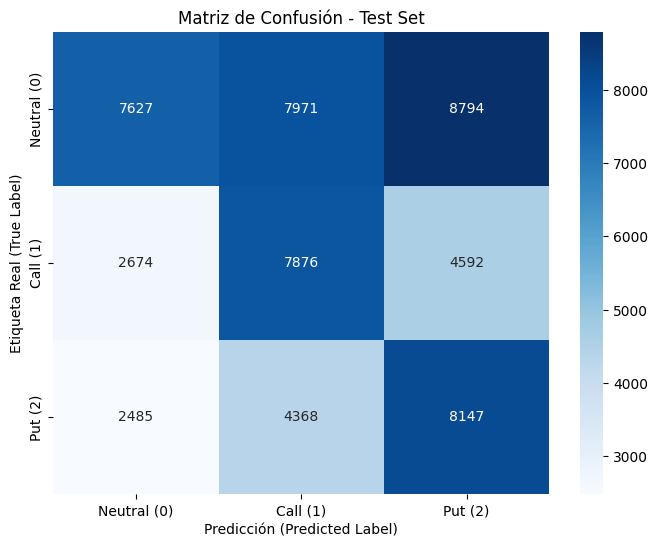

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_test_set(model, test_loader, device, model_path=None, class_names=['Neutral', 'Call', 'Put']):
    """
    Evalúa el modelo en el set de testeo y muestra métricas detalladas.
    """

    # 1. Cargar el mejor modelo guardado (Si existe path)
    if model_path and os.path.exists(model_path):
        print(f"🔄 Cargando pesos del mejor modelo desde: {model_path}")
        model.load_state_dict(torch.load(model_path, map_location=device))
    else:
        print("⚠️ Usando los pesos actuales del modelo (no se cargó desde archivo).")

    model.eval()
    all_preds = []
    all_targets = []

    # 2. Inferencia
    print("📊 Generando predicciones en Test Set...")
    with torch.no_grad():
        for X_batch, y_batch in tqdm(test_loader, desc="Evaluando"):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Nota: Tu modelo devuelve (logits, attention_weights), solo necesitamos logits
            logits, _ = model(X_batch)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    # 3. Métricas
    print("\n" + "="*60)
    print("RESULTADOS EN TEST SET")
    print("="*60)

    # Reporte de Clasificación (Incluye F1 por clase y Weighted Avg)
    print("\n📈 Reporte de Clasificación:")
    print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

    # F1 Score Global (Weighted)
    f1_final = f1_score(all_targets, all_preds, average='weighted')
    print(f"🏆 F1 Score Global (Weighted): {f1_final:.4f}")

    # 4. Matriz de Confusión Visual
    cm = confusion_matrix(all_targets, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.ylabel('Etiqueta Real (True Label)')
    plt.xlabel('Predicción (Predicted Label)')
    plt.title('Matriz de Confusión - Test Set')
    plt.show()

# --- EJECUCIÓN ---
# Asegúrate de tener definidos 'model', 'test_loader', 'device' y 'MODEL_PATH'
# Si acabas de entrenar, estas variables ya existen en tu entorno.

if 'model' in locals() and 'test_loader' in locals():
    evaluate_test_set(
        model=model,
        test_loader=test_loader,
        device=device,
        model_path=MODEL_PATH, # Usa la ruta donde guardaste el mejor modelo
        class_names=['Neutral (0)', 'Call (1)', 'Put (2)']
    )
else:
    print("❌ Por favor ejecuta primero el bloque de entrenamiento para definir el modelo y los loaders.")